In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
lr_dir = 'C:/Users/upraj/Prajwal/GSOC/Unsupervised_SR/Task 2/Dataset 6B/Dataset/LR'
hr_dir = 'C:/Users/upraj/Prajwal/GSOC/Unsupervised_SR/Task 2/Dataset 6B/Dataset/HR'
pretrained_6a = 'edsr_6a.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, num_features, res_scale=0.1):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1),
        )
        self.res_scale = res_scale

    def forward(self, x):
        return x + self.body(x) * self.res_scale


class Upsampler(nn.Module):
    def __init__(self, scale_factor, num_features):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_features, num_features * (scale_factor ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale_factor),
        )

    def forward(self, x):
        return self.body(x)


class EDSR(nn.Module):
    def __init__(self, scale_factor=2, num_features=64, num_res_blocks=16, res_scale=0.1, in_channels=1):
        super().__init__()
        self.head = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)
        self.body = nn.Sequential(
            *[ResidualBlock(num_features, res_scale) for _ in range(num_res_blocks)],
            nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        )
        self.tail = nn.Sequential(
            Upsampler(scale_factor, num_features),
            nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        head_out = self.head(x)
        body_out = self.body(head_out)
        res = head_out + body_out
        return self.tail(res)

In [4]:
class Dataset6B(Dataset):
    def __init__(self, lr_dir, hr_dir):
        self.lr_files = sorted([os.path.join(lr_dir, f) for f in os.listdir(lr_dir) if f.endswith('.npy')])
        self.hr_files = sorted([os.path.join(hr_dir, f) for f in os.listdir(hr_dir) if f.endswith('.npy')])

    def __len__(self):
        return len(self.lr_files)

    def __getitem__(self, idx):
        lr = np.load(self.lr_files[idx]).astype(np.float32)
        hr = np.load(self.hr_files[idx]).astype(np.float32)
        if lr.max() > 1.0: lr = lr / lr.max()
        if hr.max() > 1.0: hr = hr / hr.max()

        return torch.tensor(lr), torch.tensor(hr)

dataset = Dataset6B(lr_dir, hr_dir)

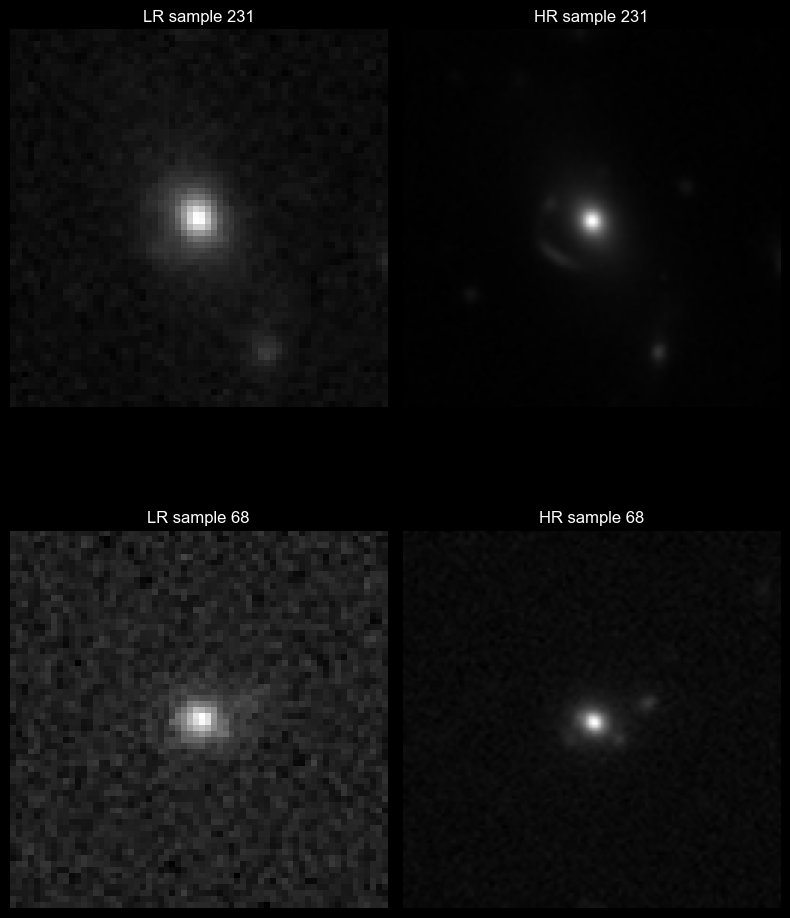

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8, 11))

indices = random.sample(range(len(dataset)), 2)

for row, index in enumerate(indices):
    lr, hr = dataset[index]
    axes[row, 0].imshow(lr.squeeze().numpy(), cmap='gray')
    axes[row, 0].set_title(f'LR sample {index}')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(hr.squeeze().numpy(), cmap='gray')
    axes[row, 1].set_title(f'HR sample {index}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

Visually I found some corrupt samples in the data, so I created a cell to detect corrupt samples based on typical types of corruption in lensing datasets

- Stripe detection checks for abnormal row or column variance ratios
- Frequency artifact detection checks if spectral energy is distributed assymetrically
- LR-HR mismatch upsamples LR and computes normalized cross correlation with HR (low score means the two images do not corresspond to a same scene)
- point source validation confirms the HR image has a prominent peak above background (it is consistent with real lensing sources)

In [6]:
def has_stripes(img, threshold=5.0):
    if img.ndim == 3:
        img = img.squeeze()

    row_var = np.var(img, axis=1).mean()
    col_var = np.var(img, axis=0).mean()
    ratio = max(row_var, col_var) / (min(row_var, col_var) + 1e-8)
    return ratio > threshold

def lr_hr_mismatch(lr, hr, threshold=0.2):
    lr_t = torch.tensor(lr).unsqueeze(0)
    lr_up = F.interpolate(lr_t, scale_factor=2, mode='bicubic', align_corners=False)
    lr_up = lr_up.squeeze().numpy()
    hr = hr.squeeze()
    # normalize
    lr_up = (lr_up - lr_up.mean()) / (lr_up.std() + 1e-8)
    hr = (hr - hr.mean()) / (hr.std() + 1e-8)
    corr = np.mean(lr_up * hr)
    return corr < threshold

def is_point_like(img, threshold=0.3):
    img = img.squeeze()
    max_val = img.max()
    mean_val = img.mean()
    # point sources have strong peak vs background
    return (max_val - mean_val) > threshold

def has_strong_frequency_pattern(img, threshold=10):
    img = img.squeeze()
    fft = np.fft.fftshift(np.fft.fft2(img))
    magnitude = np.abs(fft)
    # sum along axes
    row_energy = magnitude.mean(axis=1)
    col_energy = magnitude.mean(axis=0)
    ratio = max(row_energy.mean(), col_energy.mean()) / (min(row_energy.mean(), col_energy.mean()) + 1e-8)
    return ratio > threshold

corrupt_indices = []

for i in range(len(dataset)):
    lr, hr = dataset[i]

    lr_np = lr.numpy()
    hr_np = hr.numpy()

    try:
        # Stripe detection
        if has_stripes(hr_np):
            print(f"{i} Stripe artifact")
            corrupt_indices.append(i)
            continue

        # Frequency check
        if has_strong_frequency_pattern(hr_np):
            print(f"{i} Frequency artifact")
            corrupt_indices.append(i)
            continue

        # LR-HR mismatch
        if lr_hr_mismatch(lr_np, hr_np):
            print(f"{i} LR-HR mismatch")
            corrupt_indices.append(i)
            continue

        # Not point-like
        if not is_point_like(hr_np):
            print(f"{i} Not point-like")
            corrupt_indices.append(i)
            continue

    except Exception as e:
        print(f"[{i}] Error: {e}")
        corrupt_indices.append(i)

print("Corrupt indices:", corrupt_indices)

23 Stripe artifact
103 LR-HR mismatch
Corrupt indices: [23, 103]


In [7]:
# remove corrupt indices
all_indices = list(range(len(dataset)))
good_indices = [i for i in all_indices if i not in corrupt_indices]
clean_dataset = Subset(dataset, good_indices)

print(f"samples without corruption: {len(clean_dataset)}")

samples without corruption: 298


In [8]:
train_size = int(0.9 * len(clean_dataset))
test_size = len(clean_dataset) - train_size
train_base, test_set = random_split(clean_dataset, [train_size, test_size])

print(f"Train: {train_size} and Test: {test_size}")

Train: 268 and Test: 30


In [9]:
class AugmentedDataset(Dataset):
    def __init__(self, subset, noise_std=0.0, augment=True):
        """
        subset : Dataset
        noise_std : Gaussian noise std added to LR only at runtime. 0.0 means no noise (plain transfer learning).
        augment : if False, no transforms are applied (used for K samples later where raw images are needed).
        """
        self.data = [subset[i] for i in range(len(subset))]
        self.noise_std = noise_std
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def _random_transform(self, lr, hr):
        # 90 degree rotation on LR and HR
        k = random.randint(0, 3)
        lr = torch.rot90(lr, k, dims=[-2, -1])
        hr = torch.rot90(hr, k, dims=[-2, -1])

        # horizontal flip
        if random.random() > 0.5:
            lr = torch.flip(lr, dims=[-1])
            hr = torch.flip(hr, dims=[-1])

        # vertical flip
        if random.random() > 0.5:
            lr = torch.flip(lr, dims=[-2])
            hr = torch.flip(hr, dims=[-2])

        # brightness scale on LR only
        scale = random.uniform(0.8, 1.2)
        lr = torch.clamp(lr * scale, 0.0, 1.0)
        return lr, hr

    def __getitem__(self, idx):
        lr, hr = self.data[idx]
        lr, hr = lr.clone(), hr.clone()

        if self.augment:
            lr, hr = self._random_transform(lr, hr)
        if self.noise_std > 0:
            lr = torch.clamp(lr + torch.randn_like(lr) * self.noise_std, 0.0, 1.0)
        return lr, hr


print(f"Train base size : {len(train_base)}")
print(f"Test size : {len(test_set)}")

Train base size : 268
Test size : 30


Same combined loss as 6A

In [10]:
class SRLoss(nn.Module):
    def __init__(self, fft_weight=0.05):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.fft_weight = fft_weight

    def _fft_loss(self, pred, target):
        pred_fft = torch.fft.fft2(pred.float(), norm='ortho')
        target_fft = torch.fft.fft2(target.float(), norm='ortho')
        return F.l1_loss(torch.abs(pred_fft), torch.abs(target_fft))

    def forward(self, pred, target):
        return self.l1(pred, target) + self.fft_weight * self._fft_loss(pred, target)

In [11]:
def compute_metrics(pred, gt):
    mse_val = float(np.mean((gt - pred) ** 2))
    psnr_val = psnr(gt, pred, data_range=1.0)
    ssim_val = ssim(gt, pred, data_range=1.0)
    return mse_val, psnr_val, ssim_val


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    total_mse = 0
    total_psnr = 0
    total_ssim = 0
    count = 0
    # criterion = nn.MSELoss()
    criterion = SRLoss(fft_weight=0.05)
    with torch.no_grad():
        for lr_imgs, hr_imgs in loader:
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            preds = model(lr_imgs)
            total_loss += criterion(preds, hr_imgs).item()
            for pred, gt in zip(preds.cpu().numpy(), hr_imgs.cpu().numpy()):
                m, p, s = compute_metrics(pred.squeeze(), gt.squeeze())
                total_mse += m
                total_psnr += p
                total_ssim += s
                count += 1
    return total_loss/len(loader), total_mse/count, total_psnr/count, total_ssim/count


def load_pretrained_edsr():
    model = EDSR().to(device)
    model.load_state_dict(torch.load(pretrained_6a, map_location=device, weights_only=True))
    return model


lr_rate = 2e-5
weight_decay = 1e-4
def build_optimizer(model):
    # update head and body at lower rate as they already learned lensing features in Task 6A.
    # tail handles upsampling and adapts to new domain.
    return optim.Adam([
        {'params': model.head.parameters(), 'lr': lr_rate * 0.1},
        {'params': model.body.parameters(), 'lr': lr_rate * 0.1},
        {'params': model.tail.parameters(), 'lr': lr_rate}], weight_decay=weight_decay)


test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

# store all results
all_results = {}

### First I use the plain pretrained EDSR from 6A

I use a two stage fine-tuning.

*Stage 1*: Frozen backbone. Train tail only (head and body are frozen). The upsampling and reconstruction layers will adapt to real HSC/HST domain.

*Stage 2*: Full fine-tuning. Unfreeze all layers.


In [12]:
stage1_epochs = 30
stage2_epochs = 50
num_epochs = stage1_epochs + stage2_epochs
lr_rate_s1 = 2e-4

model_plain = load_pretrained_edsr()
criterion = SRLoss(fft_weight=0.05)

train_dataset_plain = AugmentedDataset(train_base, noise_std=0.0, augment=True)
train_loader_plain = DataLoader(train_dataset_plain, batch_size=16, shuffle=True)

train_losses_plain, test_psnrs_plain, test_ssims_plain = [], [], []
best_psnr_plain = 0.0

# Stage 1: train tail only
print(f"\n Stage 1: Frozen backbone")

for param in model_plain.head.parameters():
    param.requires_grad = False
for param in model_plain.body.parameters():
    param.requires_grad = False

optimizer_s1 = optim.Adam(filter(lambda p: p.requires_grad, model_plain.parameters()),lr=lr_rate_s1, weight_decay=weight_decay)
scheduler_s1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=stage1_epochs, eta_min=1e-6)

for epoch in range(1, stage1_epochs + 1):
    model_plain.train()
    running_loss = 0.0
    for lr_imgs, hr_imgs in tqdm(train_loader_plain, desc=f"Epoch {epoch}/{stage1_epochs}", leave=False):
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)
        optimizer_s1.zero_grad()
        preds = model_plain(lr_imgs)
        loss = criterion(preds, hr_imgs)
        loss.backward()
        optimizer_s1.step()
        running_loss += loss.item()

    scheduler_s1.step()
    avg_train_loss = running_loss / len(train_loader_plain)
    _, t_mse, t_psnr, t_ssim = evaluate(model_plain, test_loader)

    train_losses_plain.append(avg_train_loss)
    test_psnrs_plain.append(t_psnr)
    test_ssims_plain.append(t_ssim)

    if t_psnr > best_psnr_plain:
        best_psnr_plain = t_psnr
        torch.save(model_plain.state_dict(), 'edsr_plain.pth')
    if epoch % 10 == 0:
        print(f"Epoch {epoch} , Train Loss: {avg_train_loss:.4e} , "f"MSE: {t_mse:.4e} , PSNR: {t_psnr:.2f} , SSIM: {t_ssim:.4f}")

# Stage 2: full fine-tuning
print(f"\n Stage 2: Full fine-tuning")

for param in model_plain.parameters():
    param.requires_grad = True

# different lr_rate for different layers
optimizer_s2 = optim.Adam([
    {'params': model_plain.head.parameters(), 'lr': lr_rate * 0.1},
    {'params': model_plain.body.parameters(), 'lr': lr_rate * 0.1},
    {'params': model_plain.tail.parameters(), 'lr': lr_rate},], weight_decay=weight_decay)

# Short warmup then cosine decay for the longer phase 2
warmup_sched = optim.lr_scheduler.LinearLR(optimizer_s2, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine_sched = optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=max(stage2_epochs - 5, 1), eta_min=1e-7)
scheduler_s2 = optim.lr_scheduler.SequentialLR(optimizer_s2, schedulers=[warmup_sched, cosine_sched], milestones=[5])

for epoch in range(1, stage2_epochs + 1):
    model_plain.train()
    running_loss = 0.0
    for lr_imgs, hr_imgs in tqdm(train_loader_plain, desc=f"Epoch {epoch}/{stage2_epochs}", leave=False):
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)
        optimizer_s2.zero_grad()
        preds = model_plain(lr_imgs)
        loss = criterion(preds, hr_imgs)
        loss.backward()
        optimizer_s2.step()
        running_loss += loss.item()

    scheduler_s2.step()
    avg_train_loss = running_loss / len(train_loader_plain)
    _, t_mse, t_psnr, t_ssim = evaluate(model_plain, test_loader)

    train_losses_plain.append(avg_train_loss)
    test_psnrs_plain.append(t_psnr)
    test_ssims_plain.append(t_ssim)

    if t_psnr > best_psnr_plain:
        best_psnr_plain = t_psnr
        torch.save(model_plain.state_dict(), 'edsr_plain.pth')
    if epoch % 10 == 0:
        print(f"Epoch {epoch} , "f"Train Loss: {avg_train_loss:.4e} , MSE: {t_mse:.4e} , "f"PSNR: {t_psnr:.2f} , SSIM: {t_ssim:.4f}")

model_plain.load_state_dict(torch.load('edsr_plain.pth', map_location=device, weights_only=True))
_, final_mse, final_psnr, final_ssim = evaluate(model_plain, test_loader)
all_results['EDSR Plain'] = {'MSE': final_mse, 'PSNR': final_psnr, 'SSIM': final_ssim}


 Stage 1: Frozen backbone


Epoch 10 , Train Loss: 1.7051e-02 , MSE: 9.6226e-04 , PSNR: 31.64 , SSIM: 0.8188


Epoch 20 , Train Loss: 1.6468e-02 , MSE: 9.2046e-04 , PSNR: 32.10 , SSIM: 0.8412


Epoch 30 , Train Loss: 1.6490e-02 , MSE: 9.0786e-04 , PSNR: 32.12 , SSIM: 0.8371

 Stage 2: Full fine-tuning


C:\Users\upraj\anaconda3\envs\gsoc\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 10 , Train Loss: 1.6231e-02 , MSE: 8.5931e-04 , PSNR: 32.54 , SSIM: 0.8451


Epoch 20 , Train Loss: 1.6059e-02 , MSE: 7.7445e-04 , PSNR: 33.03 , SSIM: 0.8430


Epoch 30 , Train Loss: 1.6091e-02 , MSE: 7.4334e-04 , PSNR: 33.26 , SSIM: 0.8404


Epoch 40 , Train Loss: 1.5917e-02 , MSE: 7.4229e-04 , PSNR: 33.35 , SSIM: 0.8441


Epoch 50 , Train Loss: 1.5978e-02 , MSE: 7.2734e-04 , PSNR: 33.41 , SSIM: 0.8426


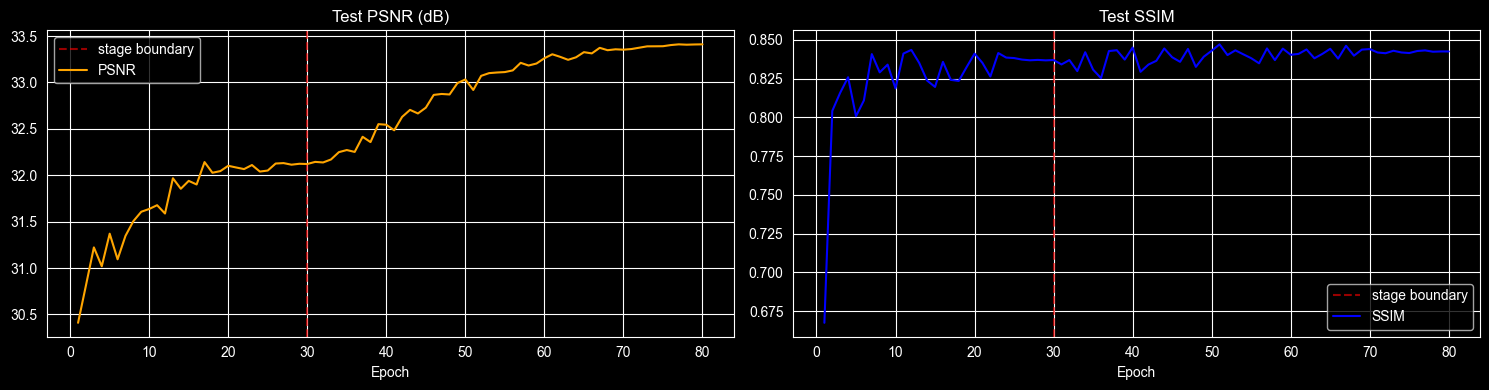

In [13]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax in axes:
    ax.axvline(x=stage1_epochs, color='red', linestyle='--',
               alpha=0.6, label='stage boundary')

axes[0].plot(epochs, test_psnrs_plain, color='orange', label='PSNR')
axes[0].set_title('Test PSNR (dB)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, test_ssims_plain, color='blue', label='SSIM')
axes[1].set_title('Test SSIM')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### I then use a Denoised EDSR with small Gaussian noise levels to LR images

Noise is only applied in Stage 2 of fine-tuning

In [14]:
noise_levels = [0.005, 0.01]

denoised_results = {}

for std in noise_levels:
    label = f'EDSR Noise std={std}'
    print(f"{label}")

    model_dn = load_pretrained_edsr()
    save_path = f'edsr_noise_{str(std).replace(".", "")}.pth'

    # no noise during stage 1
    train_dataset_n1 = AugmentedDataset(train_base, noise_std=0.0, augment=True)
    train_loader_n1 = DataLoader(train_dataset_n1, batch_size=16, shuffle=True)

    # noise injection during stage 2
    train_dataset_n2 = AugmentedDataset(train_base, noise_std=std, augment=True)
    train_loader_n2 = DataLoader(train_dataset_n2, batch_size=16, shuffle=True)

    best_psnr_dn   = 0.0
    psnrs_dn, ssims_dn = [], []

    # Stage 1: train tail only
    print(f"\n Stage 1: Frozen backbone")

    for param in model_dn.head.parameters():
        param.requires_grad = False
    for param in model_dn.body.parameters():
        param.requires_grad = False

    optimizer_s1 = optim.Adam(filter(lambda p: p.requires_grad, model_dn.parameters()),lr=lr_rate_s1, weight_decay=weight_decay)
    scheduler_s1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=stage1_epochs, eta_min=1e-6)

    for epoch in range(1, stage1_epochs + 1):
        model_dn.train()
        running_loss = 0.0
        for lr_imgs, hr_imgs in tqdm(train_loader_n1, desc=f"std={std} Epoch {epoch}/{stage1_epochs}", leave=False):
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            optimizer_s1.zero_grad()
            preds = model_dn(lr_imgs)
            loss = criterion(preds, hr_imgs)
            loss.backward()
            optimizer_s1.step()
            running_loss += loss.item()

        scheduler_s1.step()
        avg_train_loss = running_loss / len(train_loader_n1)
        _, t_mse, t_psnr, t_ssim = evaluate(model_dn, test_loader)

        psnrs_dn.append(t_psnr)
        ssims_dn.append(t_ssim)

        if t_psnr > best_psnr_dn:
            best_psnr_dn = t_psnr
            torch.save(model_dn.state_dict(), save_path)
        if epoch % 10 == 0:
            print(f"Epoch {epoch} , Train Loss: {avg_train_loss:.4e} , "f"MSE: {t_mse:.4e} , PSNR: {t_psnr:.2f} , SSIM: {t_ssim:.4f}")

    # Stage 2: full fine-tuning
    print(f"\n Stage 2: Full fine-tuning")

    for param in model_dn.parameters():
        param.requires_grad = True


    optimizer_p2 = optim.Adam([
        {'params': model_dn.head.parameters(), 'lr': lr_rate * 0.1},
        {'params': model_dn.body.parameters(), 'lr': lr_rate * 0.1},
        {'params': model_dn.tail.parameters(), 'lr': lr_rate},], weight_decay=weight_decay)

    warmup_sched = optim.lr_scheduler.LinearLR(optimizer_p2, start_factor=0.1, end_factor=1.0, total_iters=5)
    cosine_sched = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=max(stage2_epochs - 5, 1), eta_min=1e-7)
    scheduler_p2 = optim.lr_scheduler.SequentialLR(optimizer_p2, schedulers=[warmup_sched, cosine_sched], milestones=[5])

    for epoch in range(1, stage2_epochs + 1):
        model_dn.train()
        running_loss = 0.0
        for lr_imgs, hr_imgs in tqdm(train_loader_n2, desc=f"std={std} Epoch {epoch}/{stage2_epochs}", leave=False):
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            optimizer_s2.zero_grad()
            preds = model_dn(lr_imgs)
            loss = criterion(preds, hr_imgs)
            loss.backward()
            optimizer_s2.step()
            running_loss += loss.item()

        scheduler_s2.step()
        avg_train_loss = running_loss / len(train_loader_n2)
        _, t_mse, t_psnr, t_ssim = evaluate(model_dn, test_loader)

        psnrs_dn.append(t_psnr)
        ssims_dn.append(t_ssim)

        if t_psnr > best_psnr_dn:
            best_psnr_dn = t_psnr
            torch.save(model_dn.state_dict(), save_path)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} , "f"Train Loss: {avg_train_loss:.4e} , MSE: {t_mse:.4e} , "f"PSNR: {t_psnr:.2f} , SSIM: {t_ssim:.4f}")

    model_dn.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    _, final_mse, final_psnr, final_ssim = evaluate(model_dn, test_loader)
    denoised_results[label] = {'MSE': final_mse, 'PSNR': final_psnr, 'SSIM': final_ssim, 'psnrs': psnrs_dn, 'ssims': ssims_dn }
    all_results[label] = {'MSE': final_mse, 'PSNR': final_psnr, 'SSIM': final_ssim}

EDSR Noise std=0.005

 Stage 1: Frozen backbone


Epoch 10 , Train Loss: 1.7066e-02 , MSE: 1.0068e-03 , PSNR: 31.42 , SSIM: 0.8065


Epoch 20 , Train Loss: 1.6690e-02 , MSE: 9.3339e-04 , PSNR: 32.02 , SSIM: 0.8413


Epoch 30 , Train Loss: 1.6410e-02 , MSE: 9.0143e-04 , PSNR: 32.17 , SSIM: 0.8375

 Stage 2: Full fine-tuning


Epoch 10 , Train Loss: 1.6432e-02 , MSE: 9.0143e-04 , PSNR: 32.17 , SSIM: 0.8375


...

Epoch 10 , Train Loss: 1.6466e-02 , MSE: 9.1111e-04 , PSNR: 32.08 , SSIM: 0.8365


Epoch 20 , Train Loss: 1.6107e-02 , MSE: 9.1111e-04 , PSNR: 32.08 , SSIM: 0.8365


Epoch 30 , Train Loss: 1.6649e-02 , MSE: 9.1111e-04 , PSNR: 32.08 , SSIM: 0.8365


Epoch 40 , Train Loss: 1.6435e-02 , MSE: 9.1111e-04 , PSNR: 32.08 , SSIM: 0.8365


Epoch 50 , Train Loss: 1.6629e-02 , MSE: 9.1111e-04 , PSNR: 32.08 , SSIM: 0.8365


In [15]:
print(f"{'Model':<28} {'MSE':>10} {'PSNR (dB)':>12} {'SSIM':>10}")
for name, r in all_results.items():
    print(f"{name:<28} {r['MSE']:>10.6f} {r['PSNR']:>12.4f} {r['SSIM']:>10.6f}")

Model                               MSE    PSNR (dB)       SSIM
EDSR Plain                     0.000727      33.4104   0.842582
EDSR Noise std=0.005           0.000883      32.2187   0.835272
EDSR Noise std=0.01            0.000909      32.0817   0.836051


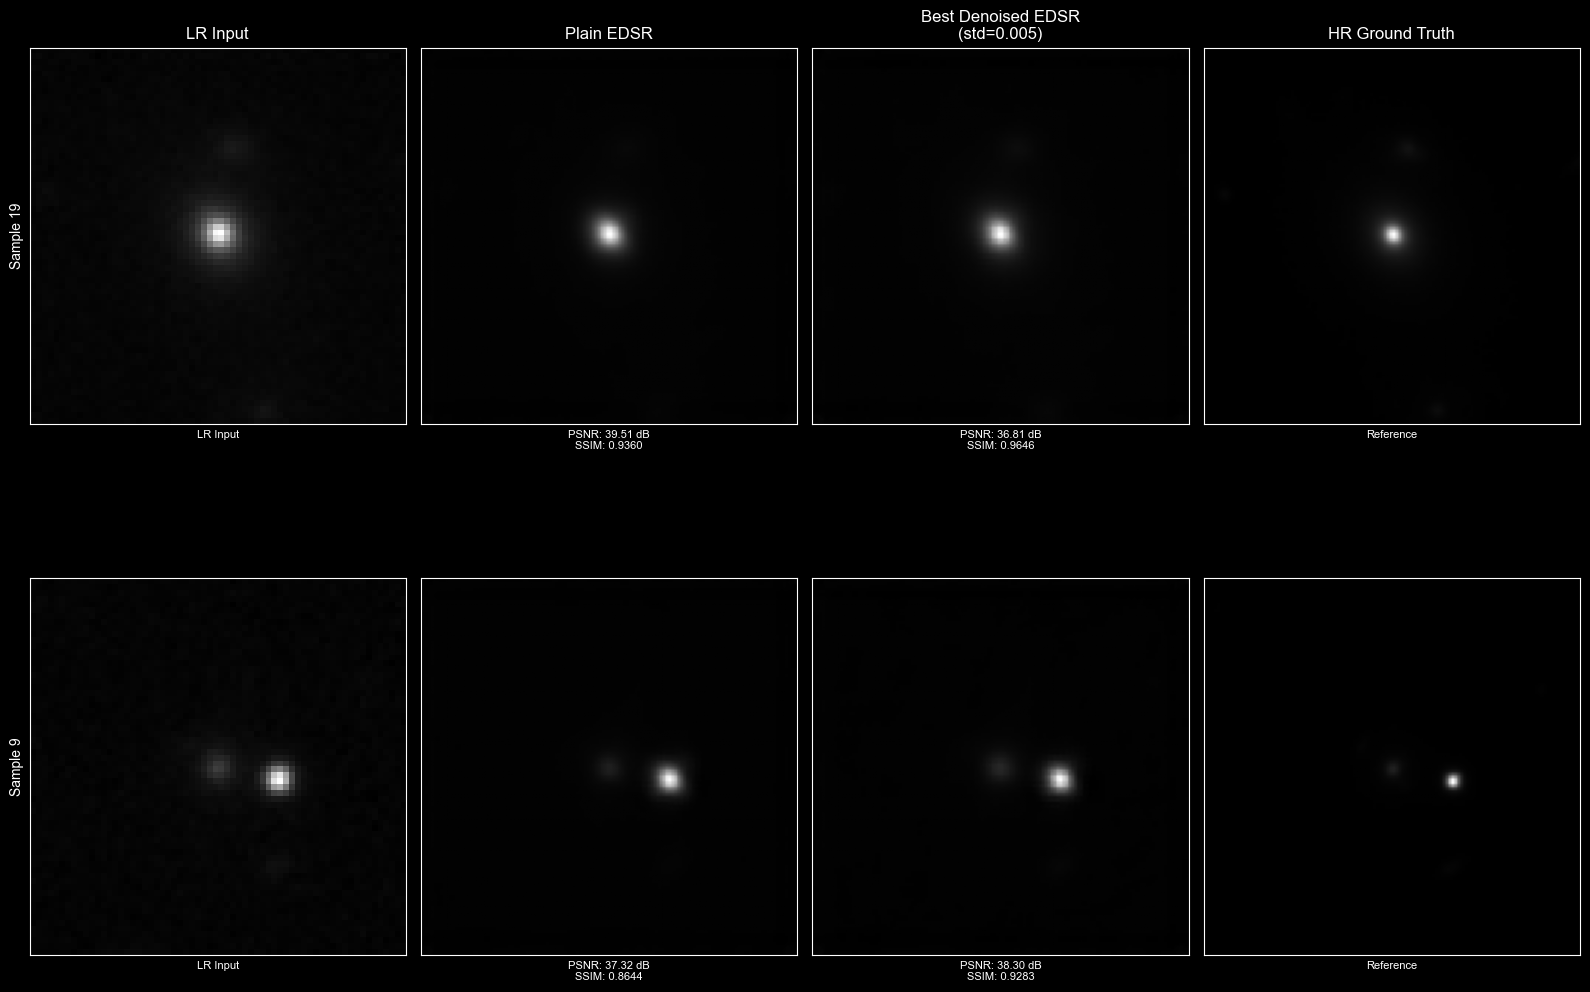

In [16]:
# 2 test samples with highest average PSNR across plain and best denoised model

# Identify best denoised model by PSNR
best_denoised_label_temp = max(denoised_results, key=lambda k: denoised_results[k]['PSNR'])
best_std = float(best_denoised_label_temp.split('=')[1])
best_path = f"edsr_noise_{str(best_std).replace('.', '')}.pth"

model_best = load_pretrained_edsr()
model_best.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
model_best.eval()
model_plain.eval()

per_sample_scores = []

for idx in range(len(test_set)):
    lr, hr = test_set[idx]
    hr_np = hr.squeeze().numpy()
    with torch.no_grad():
        plain_out = model_plain(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        best_out = model_best(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
    _, pp, _ = compute_metrics(plain_out, hr_np)
    _, bp, _ = compute_metrics(best_out,  hr_np)
    per_sample_scores.append((idx, (pp + bp) / 2))

top2_indices = [idx for idx, _ in sorted(per_sample_scores, key=lambda x: x[1], reverse=True)[:2]]

fig, axes = plt.subplots(2, 4, figsize=(16, 12))

cols = ['LR Input', 'Plain EDSR', f'Best Denoised EDSR\n(std={best_std})', 'HR Ground Truth']
for col, title in enumerate(cols):
    axes[0, col].set_title(title)

for row, index in enumerate(top2_indices):
    lr, hr = test_set[index]
    hr_np = hr.squeeze().numpy()
    lr_np = lr.squeeze().numpy()

    with torch.no_grad():
        plain_out = model_plain(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        best_out = model_best(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()

    _, pp, ps = compute_metrics(plain_out, hr_np)
    _, bp, bs = compute_metrics(best_out,  hr_np)

    imgs = [lr_np, plain_out, best_out, hr_np]
    labels = ['LR Input', f'PSNR: {pp:.2f} dB\nSSIM: {ps:.4f}', f'PSNR: {bp:.2f} dB\nSSIM: {bs:.4f}', 'Reference' ]

    for col, (img, label) in enumerate(zip(imgs, labels)):
        axes[row, col].imshow(np.clip(img, 0, 1), cmap='gray')
        axes[row, col].set_xlabel(label, fontsize=8)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    axes[row, 0].set_ylabel(f'Sample {index}', fontsize=10)

plt.tight_layout()
plt.show()

Let's now try with small data

### I then fine-tune with very small data size and with a frozen backbone
- I train only on the tail with K randomly sampled images. The model trains on a small set of real images (no augmentation).

In [17]:
K = [10, 20, 30, 40]
train_data_k = AugmentedDataset(train_base, noise_std=0.0, augment=False)

In [18]:
k_results = {}
k_epochs = 200

for K in K:
    label = f'K={K}'
    print(f"K={K} samples")

    # Load pretrained weights for each K experiment
    model_k = load_pretrained_edsr()

    # only tail is trainable
    for param in model_k.head.parameters():
        param.requires_grad = False
    for param in model_k.body.parameters():
        param.requires_grad = False

    opt_k = optim.Adam(filter(lambda p: p.requires_grad, model_k.parameters()),lr=lr_rate, weight_decay=weight_decay)
    sched_k = optim.lr_scheduler.ReduceLROnPlateau(opt_k, mode='min', factor=0.5, patience=15, min_lr=1e-8)

    save_path_k = f'edsr_samples_K{K}.pth'
    best_psnr_k = 0.0
    psnrs_k, ssims_k = [], []

    for epoch in range(1, k_epochs + 1):
        model_k.train()

        # Sample K images from the real training data each epoch
        k_indices = random.sample(range(len(train_data_k)), K)
        lr_batch = torch.stack([train_data_k[i][0] for i in k_indices]).to(device)
        hr_batch = torch.stack([train_data_k[i][1] for i in k_indices]).to(device)

        opt_k.zero_grad()
        preds = model_k(lr_batch)
        loss = criterion(preds, hr_batch)
        loss.backward()
        opt_k.step()
        _, t_mse, t_psnr, t_ssim = evaluate(model_k, test_loader)
        sched_k.step(t_mse)
        psnrs_k.append(t_psnr)
        ssims_k.append(t_ssim)

        if t_psnr > best_psnr_k:
            best_psnr_k = t_psnr
            torch.save(model_k.state_dict(), save_path_k)

        if epoch % 20 == 0:
            print(f"Epoch {epoch} , Loss: {loss.item():.4e} , "f"MSE: {t_mse:.4e} , PSNR: {t_psnr:.2f} , SSIM: {t_ssim:.4f}")

    model_k.load_state_dict(torch.load(save_path_k, map_location=device, weights_only=True))
    _, final_mse, final_psnr, final_ssim = evaluate(model_k, test_loader)
    k_results[label] = {'MSE': final_mse, 'PSNR': final_psnr, 'SSIM': final_ssim, 'psnrs': psnrs_k, 'ssims': ssims_k }
    all_results[label] = {'MSE': final_mse, 'PSNR': final_psnr, 'SSIM': final_ssim}

K=10 samples
Epoch 20 , Loss: 4.3353e-02 , MSE: 4.0744e-03 , PSNR: 27.06 , SSIM: 0.4738
Epoch 40 , Loss: 2.2070e-02 , MSE: 1.4205e-03 , PSNR: 30.93 , SSIM: 0.6379
Epoch 60 , Loss: 1.5003e-02 , MSE: 1.1629e-03 , PSNR: 31.15 , SSIM: 0.7020
Epoch 80 , Loss: 1.4929e-02 , MSE: 1.1276e-03 , PSNR: 31.13 , SSIM: 0.7366
Epoch 100 , Loss: 2.1411e-02 , MSE: 1.1104e-03 , PSNR: 31.09 , SSIM: 0.7586
Epoch 120 , Loss: 2.2538e-02 , MSE: 1.0637e-03 , PSNR: 31.25 , SSIM: 0.7830
Epoch 140 , Loss: 1.7643e-02 , MSE: 1.0161e-03 , PSNR: 31.38 , SSIM: 0.7872
Epoch 160 , Loss: 1.3348e-02 , MSE: 1.0889e-03 , PSNR: 31.15 , SSIM: 0.8112
Epoch 180 , Loss: 1.1377e-02 , MSE: 1.0551e-03 , PSNR: 31.21 , SSIM: 0.8091
Epoch 200 , Loss: 2.0734e-02 , MSE: 1.0485e-03 , PSNR: 31.22 , SSIM: 0.8083
K=20 samples
Epoch 20 , Loss: 3.6490e-02 , MSE: 4.0169e-03 , PSNR: 27.13 , SSIM: 0.4763
Epoch 40 , Loss: 2.8275e-02 , MSE: 1.3470e-03 , PSNR: 31.03 , SSIM: 0.6463
Epoch 60 , Loss: 1.4779e-02 , MSE: 1.1827e-03 , PSNR: 31.05 , SSIM: 

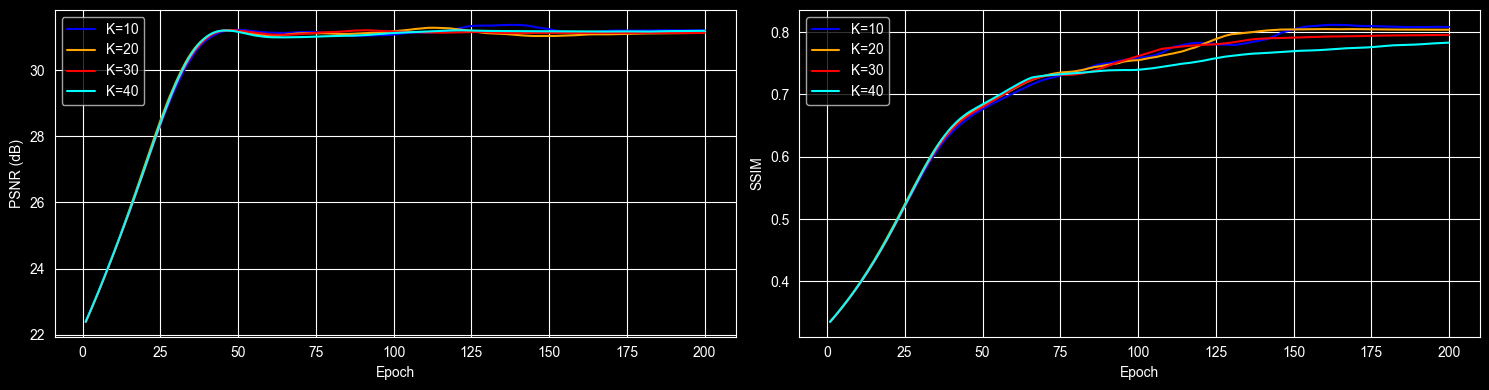

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
colors = ['blue', 'orange', 'red', 'cyan']

for (label, r), color in zip(k_results.items(), colors):
    axes[0].plot(range(1, k_epochs+1), r['psnrs'], label=label, color=color)
    axes[1].plot(range(1, k_epochs+1), r['ssims'], label=label, color=color)

for ax, ylabel in zip(axes, ['PSNR (dB)', 'SSIM']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

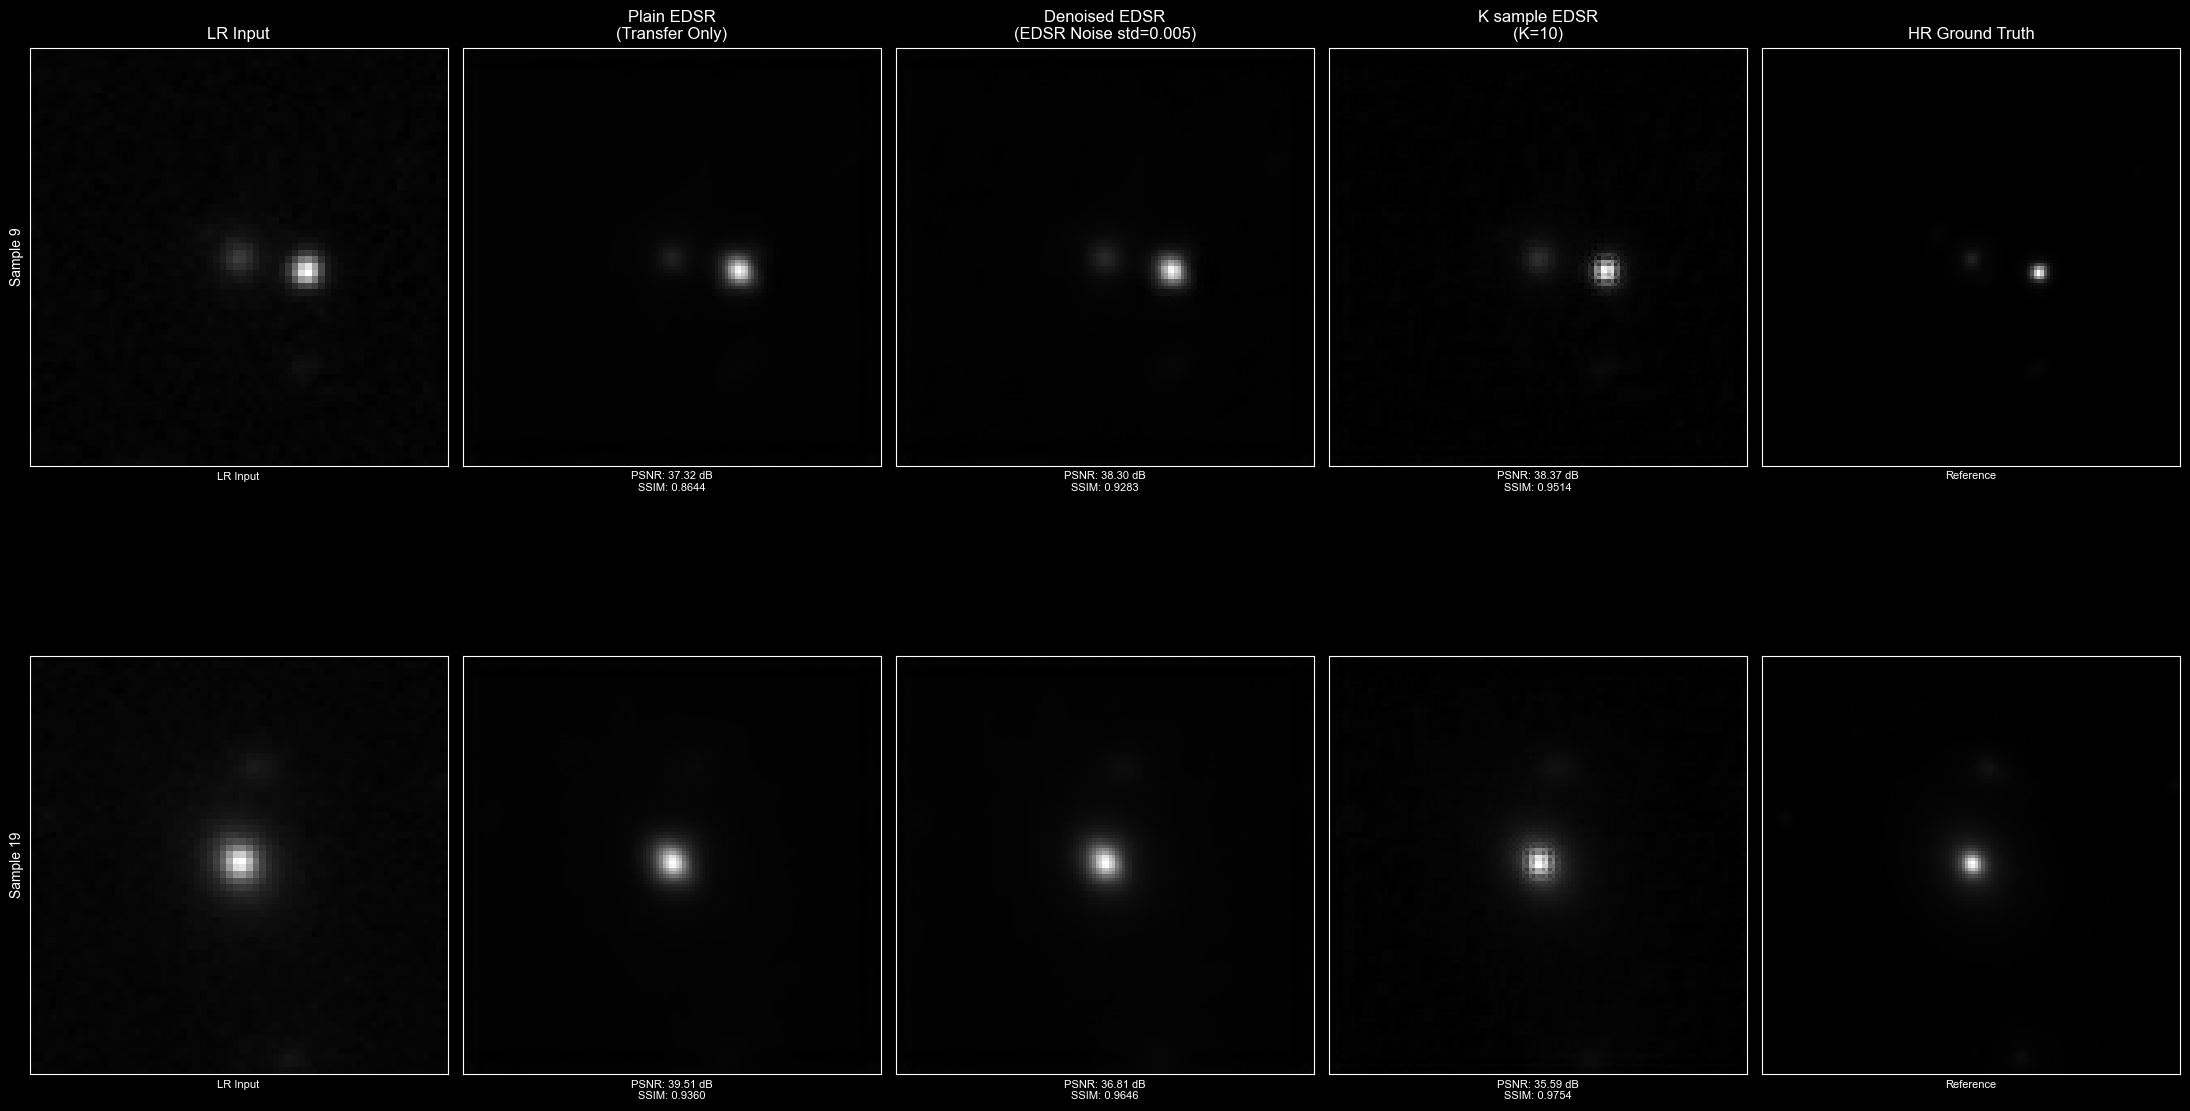

In [20]:
# best model from each category
best_denoised_label = max(denoised_results, key=lambda k: denoised_results[k]['PSNR'])
best_denoised_std = float(best_denoised_label.split('=')[1])
best_denoised_path = f"edsr_noise_{str(best_denoised_std).replace('.', '')}.pth"

best_k_label = max(k_results, key=lambda k: k_results[k]['PSNR'])
best_k = int(best_k_label.split('=')[1])
best_fs_path = f'edsr_samples_K{best_k}.pth'

# load all 3 models
model_plain.load_state_dict(torch.load('edsr_plain.pth', map_location=device, weights_only=True))
model_plain.eval()

model_denoised = load_pretrained_edsr()
model_denoised.load_state_dict(torch.load(best_denoised_path, map_location=device, weights_only=True))
model_denoised.eval()

model_k_samples = load_pretrained_edsr()
for param in model_k_samples.head.parameters():
    param.requires_grad = False
for param in model_k_samples.body.parameters():
    param.requires_grad = False
model_k_samples.load_state_dict(torch.load(best_fs_path, map_location=device, weights_only=True))
model_k_samples.eval()

# top 2 test samples by average PSNR across all three models
per_sample_scores = []

for index in range(len(test_set)):
    lr, hr = test_set[index]
    hr_np = hr.squeeze().numpy()
    with torch.no_grad():
        p1 = model_plain(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        p2 = model_denoised(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        p3 = model_k_samples(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
    _, psnr1, _ = compute_metrics(p1, hr_np)
    _, psnr2, _ = compute_metrics(p2, hr_np)
    _, psnr3, _ = compute_metrics(p3, hr_np)
    per_sample_scores.append((index, (psnr1 + psnr2 + psnr3) / 3))

top2_indices = [index for index, _ in sorted(per_sample_scores, key=lambda x: x[1], reverse=True)[:2]]

fig, axes = plt.subplots(2, 5, figsize=(22, 14))

cols = ['LR Input', 'Plain EDSR\n(Transfer Only)', f'Denoised EDSR\n({best_denoised_label})', f'K sample EDSR\n({best_k_label})', 'HR Ground Truth']
for col, title in enumerate(cols):
    axes[0, col].set_title(title)

for row, index in enumerate(top2_indices):
    lr, hr = test_set[index]
    hr_np = hr.squeeze().numpy()
    lr_np = lr.squeeze().numpy()

    with torch.no_grad():
        plain_out = model_plain(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        denoised_out = model_denoised(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()
        k_out = model_k_samples(lr.unsqueeze(0).to(device)).squeeze().cpu().numpy()

    _, plain_psnr, plain_ssim = compute_metrics(plain_out, hr_np)
    _, denoised_psnr, denoised_ssim = compute_metrics(denoised_out, hr_np)
    _, k_psnr, k_ssim = compute_metrics(k_out, hr_np)

    imgs   = [lr_np, plain_out, denoised_out, k_out, hr_np]
    labels = [ 'LR Input', f'PSNR: {plain_psnr:.2f} dB\nSSIM: {plain_ssim:.4f}', f'PSNR: {denoised_psnr:.2f} dB\nSSIM: {denoised_ssim:.4f}', f'PSNR: {k_psnr:.2f} dB\nSSIM: {k_ssim:.4f}', 'Reference']

    for col, (img, label) in enumerate(zip(imgs, labels)):
        axes[row, col].imshow(np.clip(img, 0, 1), cmap='gray')
        axes[row, col].set_xlabel(label, fontsize=8)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    axes[row, 0].set_ylabel(f'Sample {index}', fontsize=10)
plt.tight_layout()
plt.show()